In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import ploty.express as px
# import ploty.graph_objects as go
import pyodbc 
import sqlalchemy as sa # Pandas has a method for reading in sql-tables into pandas DataFrames. However, it only accepts sqlalchemy-connections
from sqlalchemy.engine import URL
from sqlalchemy import create_engine

In [2]:
[x for x in pyodbc.drivers()]

['SQL Server',
 'ODBC Driver 17 for SQL Server',
 'SQL Server Native Client RDA 11.0']

In [3]:
# Using pydbc as it was recommended by microsoft and I am trying to connect to a db created in ssms by microsoft

Database = "Industrial_db"
Server = r"TowerPC\SQLEXPRESS" 

# These were set in SSMS under the Security Directory
user = "uid"
pwd = "Testing"

cnxn = pyodbc.connect("Driver={ODBC Driver 17 for SQL Server};" # found by searing for odbc and going to the 'Drivers' tab
                      f"Server={Server};"
                      f"Database={Database};"
                      "Trusted_Connection=yes;"
                     f"uid={user};"
                     f"pwd={pwd}")

cursor = cnxn.cursor()

cursor.execute('SELECT COUNT(*) FROM equipment_anomaly_data')
for output in cursor:
    print(output)

cursor.execute('EXEC sp_columns equipment_anomaly_data')
for output in cursor:
    print(output)

cnxn.close() 

(7672,)
('Industrial_db', 'dbo', 'equipment_anomaly_data', 'temperature', 6, 'float', 15, 8, None, 10, 1, None, None, 6, None, None, 1, 'YES', 109)
('Industrial_db', 'dbo', 'equipment_anomaly_data', 'pressure', 6, 'float', 15, 8, None, 10, 1, None, None, 6, None, None, 2, 'YES', 109)
('Industrial_db', 'dbo', 'equipment_anomaly_data', 'vibration', 6, 'float', 15, 8, None, 10, 1, None, None, 6, None, None, 3, 'YES', 109)
('Industrial_db', 'dbo', 'equipment_anomaly_data', 'humidity', 6, 'float', 15, 8, None, 10, 1, None, None, 6, None, None, 4, 'YES', 109)
('Industrial_db', 'dbo', 'equipment_anomaly_data', 'equipment', -9, 'nvarchar', 50, 100, None, None, 1, None, None, -9, None, 100, 5, 'YES', 39)
('Industrial_db', 'dbo', 'equipment_anomaly_data', 'location', -9, 'nvarchar', 50, 100, None, None, 1, None, None, -9, None, 100, 6, 'YES', 39)
('Industrial_db', 'dbo', 'equipment_anomaly_data', 'faulty', 6, 'float', 15, 8, None, 10, 1, None, None, 6, None, None, 7, 'YES', 109)


In [4]:
# SQLalchemy connection-string
pyodbc_connection_string = "DRIVER={ODBC Driver 17 for SQL Server}" + f";SERVER={Server};DATABASE={Database};UID={user};PWD={pwd};Trusted_Connection=yes;"
connection_url =  URL.create("mssql+pyodbc", query={"odbc_connect": pyodbc_connection_string})
engine = create_engine(connection_url)
query = "SELECT * FROM equipment_anomaly_data"

with engine.begin() as conn:
    df = pd.read_sql_query(sa.text(query), conn)

df.head()

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,5.818018e+15,2.502928e+15,6.065162e+15,4.569491e+16,Turbine,Atlanta,0.0
1,7.574071e+15,2.295402e+15,2.338095e+16,4.186741e+16,Compressor,Chicago,0.0
2,7.135859e+15,2.727683e+15,1.389198e+16,5.895441e+15,Turbine,San Francisco,0.0
3,7.161699e+15,3.224292e+15,1.770690e+16,4.056514e+15,Pump,Atlanta,0.0
4,6.650683e+15,4.519747e+15,3.453980e+16,4.325379e+16,Pump,New York,0.0


# First Look into the data before analysis

In [5]:
any_nans = np.sum(df.isna().to_numpy().flatten())
print(f"The dataset contains {any_nans} nans.")

The dataset contains 0 nans.


In [6]:
df.loc[:, "faulty_binary"] = df.loc[:, "faulty"] != 0 # Turn into binary True/ False

nr_faulty = np.sum(df.faulty_binary == True)
nr_working = np.sum(df.faulty_binary == False)
print(f"Dataset contains entries for {df.shape[0]} machines. {nr_faulty}({nr_faulty/df.shape[0]:.2%}) are faulty and {nr_working}({nr_working/df.shape[0]:.2%}) are functioning.")

Dataset contains entries for 7672 machines. 767(10.00%) are faulty and 6905(90.00%) are functioning.


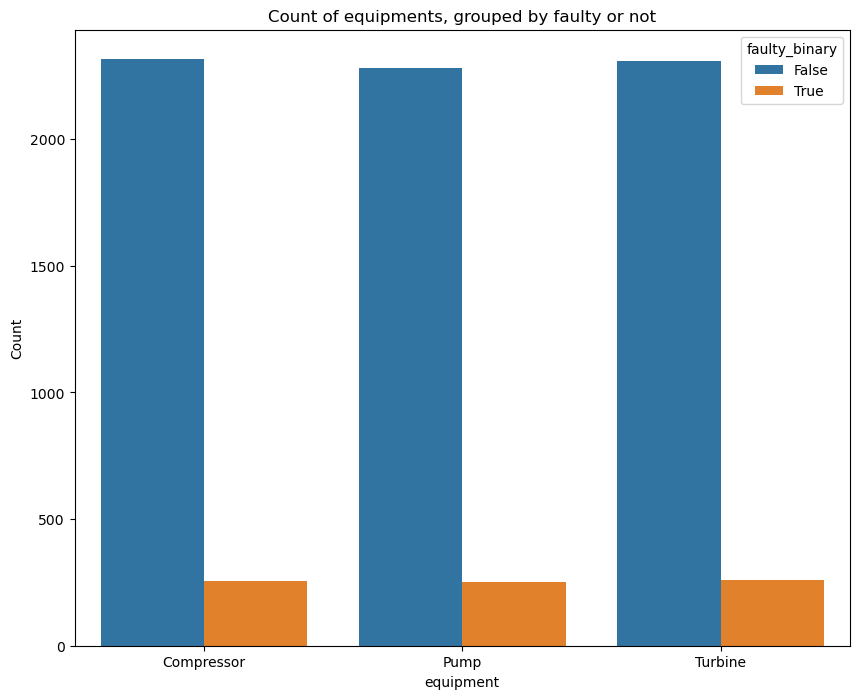

In [7]:
df_grouped = df.groupby(["equipment", "faulty_binary"]).count().iloc[:, 0]
df_grouped = df_grouped.rename("Count")
df_grouped = df_grouped.reset_index()

fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot()
sns.barplot(x="equipment", y="Count", hue="faulty_binary", data=df_grouped, ax = ax)
ax.set_title("Count of equipments, grouped by faulty or not")
plt.show()

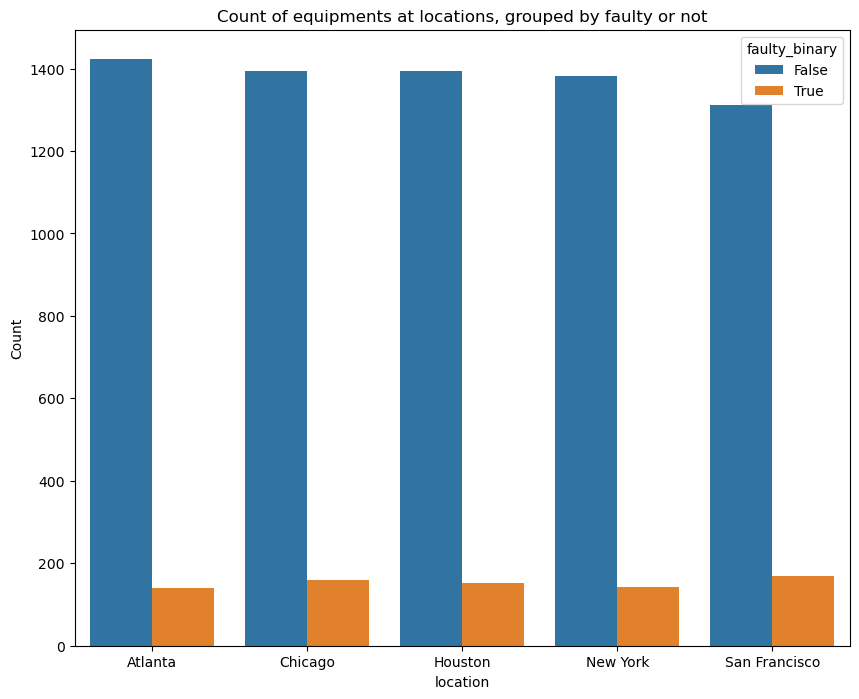

In [8]:
df_grouped = df.groupby(["location", "faulty_binary"]).count().iloc[:, 0]
df_grouped = df_grouped.rename("Count")
df_grouped = df_grouped.reset_index()

fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot()
sns.barplot(x="location", y="Count", hue="faulty_binary", data=df_grouped, ax = ax)
ax.set_title("Count of equipments at locations, grouped by faulty or not")
plt.show()

# Start Analysis-Prep

In [9]:
df_analysis = df.copy()# .drop(columns = ["faulty"])
location_labels, location_levels = df_analysis.loc[:, "location"].factorize()
equipment_labels, equipment_levels = df_analysis.loc[:, "equipment"].factorize()
df_analysis.loc[:, "location_factorized"] = location_labels
df_analysis.loc[:, "equipment_factorized"] = equipment_labels
df_analysis.drop(inplace = True, columns = ["equipment", "location", "faulty"])

Y = df_analysis.loc[:, "faulty_binary"]
X = df_analysis.drop(columns = ["faulty_binary"])

# Np imputation/ removal required as no Nans. Standardize X
X = (X - np.mean(X, axis = 0))/np.std(X, axis = 0)
X

,temperature,pressure,vibration,humidity,location_factorized,equipment_factorized
0,-0.330453,-0.833244,-0.702213,1.522631,-1.400470,-1.221684
1,-0.203069,-0.846897,1.401819,1.325791,-0.697532,0.004956
2,-0.234857,-0.818458,0.248820,-0.524170,0.005406,-1.221684
3,-0.232983,-0.785787,0.712368,-0.618742,-1.400470,1.231596
4,-0.270052,-0.700562,2.757725,1.397090,0.708344,1.231596
...,...,...,...,...,...,...
7667,-0.275821,-0.751163,1.028087,-0.573659,0.708344,1.231596
7668,-0.295448,-0.700781,-1.285528,-0.508994,0.708344,1.231596
7669,-0.747268,1.288734,0.637465,1.742640,-1.400470,1.231596
7670,0.024313,-0.841633,-0.050916,0.405262,-1.400470,0.004956


### Dimensionality reduction

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import tensorflow as tf

In [91]:
# Linear dimensionality reduction: PCA
pca = PCA(n_components = 3)
# Non-linear dimensioanlity reduciton 1: T-SNE
tsne = TSNE(n_components = 3)
# Non-liner dimensitonality reduciton 3: Autoencoder
class Autoencoder:
    def __init__(self, In_Features, Out_Features):
        self.In_Features = In_Features
        self.Out_Features = Out_Features

    def _build_autoencoder(self):
        """
        Build encoder and decoder seperatly and combine into the autoencoder-model
        """
        #### encoder
        encoder_input = tf.keras.layers.Input(shape = (self.In_Features))
        X = encoder_input
        for i in np.arange(self.In_Features-1, self.Out_Features+1, -1):
            X = tf.keras.layers.Dense(i)(X)
            X = tf.keras.layers.ReLU()(X)
        encoder_output = tf.keras.layers.Dense(self.Out_Features)(X)
        encoder = tf.keras.Model(inputs = encoder_input, outputs = encoder_output)
    
        ##### decoder
        decoder_input = tf.keras.layers.Input(shape = (self.Out_Features))
        X = decoder_input
        for i in np.arange(self.Out_Features+1, self.In_Features-1, +1):
            X = tf.keras.layers.Dense(i)(X)
            X = tf.keras.layers.ReLU()(X)
        decoder_output = tf.keras.layers.Dense(self.In_Features)(X)
        decoder = tf.keras.Model(inputs = decoder_input, outputs = decoder_output)
    
        #### autoecoder
        autoencoder = tf.keras.Sequential([encoder, decoder])
        return autoencoder
    
    def fit(self, X, verbose = 0, print_score = True):
        """
        Build a new autoendoer and train it.
        """
        self.autoencoder = self._build_autoencoder()
        loss = tf.keras.losses.MeanSquaredError()
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005)
        epochs = 20
        self.autoencoder.compile(loss=loss, optimizer=optimizer)

        X_train, X_val = train_test_split(X, train_size = 0.8)
        history = self.autoencoder.fit(x = X_train, y = X_train, epochs=epochs, verbose=verbose)
        score = self.autoencoder.evaluate(X_val, X_val)
        if print_score:
            print(f"Autoencoder has a validation loss of {score:.6f}")

    def transform(self, X):
        """
        Isolate the decoder from the trained autoencoder and transform the data X
        """
        decoder = tf.keras.Model(inputs = self.autoencoder.layers[0].input, outputs = self.autoencoder.layers[0].outputs) # isolate the trained decoder
        loss = tf.keras.losses.MeanSquaredError()
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005)
        decoder.compile(loss=loss, optimizer=optimizer)

        X_transformed = decoder.predict(X)
        return X_transformed

    def fit_transform(self, X, verbose = 0, print_score = True):
        self.fit(X, verbose = verbose, print_score = print_score)
        X_transformed = self.transform(X)
        return X_transformed

autoencoder = Autoencoder(In_Features = X.shape[1], Out_Features = 3)

## Models to compare

In [92]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [143]:
knc = KNeighborsClassifier(n_neighbors=5) # default settings
rfc = RandomForestClassifier(n_estimators=100) # default settings
svc = SVC() # default settings

class NN_Model:
    def __init__(self, out_features):
        # self.in_features = in_features
        self.out_features = out_features

    def _build_model(self, X):
        self.in_features = X.shape[1]
        X_input = tf.keras.layers.Input(shape = (self.in_features))
        X = X_input
        for features in np.arange(1000, 200, -200):
            X = tf.keras.layers.Dense(features)(X)
            X = tf.keras.layers.Dropout(0.2)(X)
            X = tf.keras.layers.BatchNormalization(axis = -1)(X)
            X = tf.keras.layers.ReLU()(X)
        X_output = tf.keras.layers.Dense(self.out_features)(X)

        model = tf.keras.Model(inputs = X_input, outputs = X_output)

        return model

    def fit(self, X_train, y_train, verbose = 1):
        self.model = self._build_model(X_train)
        loss = tf.keras.losses.CategoricalCrossentropy(from_logits = True)
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005)
        earlyStop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-10, patience=10)
        self.model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])
        epochs = 50

        self.history = self.model.fit(x = X_train, y = tf.one_hot(y_train, self.out_features), epochs=epochs, verbose=verbose, validation_split=0.2, callbacks=[earlyStop])

    def eval(self, X_val, y_val):
        score = self.model.evaluate(X_val, tf.one_hot(y_val, self.out_features))
        return score

    def predict(self, X_test, as_text = False):
        output = self.model.predict(X_test)
        y_pred = np.argmax(tf.nn.softmax(output), axis = 1)
        if as_text:
            y_pred = np.array(["Faulty" if i == 1 else "Not faulty" for i in y_pred ])
        return y_pred

nn_model = NN_Model(out_features = 2)

## CrossValidations

In [94]:
from sklearn.model_selection import ShuffleSplit
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

In [95]:
def eval_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train.to_numpy().flatten())
    y_pred = model.predict(X_val)
    acc = np.mean(y_pred.flatten() == y_val.to_numpy().flatten())
    return acc

### K-NN

In [96]:
knn_quality = {"Unreduced": [],
              "PCA": [],
              "T-SNE": [],
              "Autoencoder": []}

for i ,(train_index, val_index) in enumerate(cv.split(X)):
    print(f"Round {i+1} of 10")
    # unreduced data
    print("Start Testing: Unreduced")
    X_train, y_train = X.iloc[train_index, :], Y.iloc[train_index]
    X_val, y_val = X.iloc[val_index, :], Y.iloc[val_index]
    original_acc = eval_model(knc, X_train, y_train, X_val, y_val)
    knn_quality["Unreduced"].append(original_acc)
    
    # pca transformed
    print("Start Testing: PCA")
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    pca_acc = eval_model(knc, X_train_pca, y_train, X_val_pca, y_val)
    knn_quality["PCA"].append(pca_acc)

    # tsne transformed
    print("Start Testing: T-SNE")
    X_train_tsne = tsne.fit_transform(X_train)
    X_val_tsne = tsne.fit_transform(X_val) # does not have a sole transform method
    tsne_acc = eval_model(knc, X_train_tsne, y_train, X_val_tsne, y_val)
    knn_quality["T-SNE"].append(tsne_acc)

    # autoencoder transfordmed
    print("Start Testing: Autoencoder")
    X_train_ac = autoencoder.fit_transform(X_train)
    X_val_ac = autoencoder.transform(X_val)
    ac_acc = eval_model(knc, X_train_ac, y_train, X_val_ac, y_val)
    knn_quality["Autoencoder"].append(ac_acc)

    print()

Round 1 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 895us/step - loss: 0.4702
Autoencoder has a validation loss of 0.470196
48/48 [==============================] - 0s 723us/step
Round 2 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 868us/step - loss: 0.4401
Autoencoder has a validation loss of 0.440110
48/48 [==============================] - 0s 723us/step
Round 3 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 895us/step - loss: 0.4403
Autoencoder has a validation loss of 0.440293
48/48 [==============================] - 0s 723us/step
Round 4 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 895us/step - loss: 

In [98]:
for key, value in knn_quality.items():
    Median = np.median(value)
    print(f"k-NN (data being {'unreduced' if key == 'Unreduced' else 'dimensioanlity reduced using ' + key}) has a median accuracy of {Median:.4}")

k-NN (data being unreduced) has a median accuracy of 0.9218
k-NN (data being dimensioanlity reduced using PCA) has a median accuracy of 0.9007
k-NN (data being dimensioanlity reduced using T-SNE) has a median accuracy of 0.8007
k-NN (data being dimensioanlity reduced using Autoencoder) has a median accuracy of 0.9036


### Random Tree Classifier

In [99]:
rfc_quality = {"Unreduced": [],
              "PCA": [],
              "T-SNE": [],
              "Autoencoder": []}

for i ,(train_index, val_index) in enumerate(cv.split(X)):
    print(f"Round {i+1} of 10")
    # unreduced data
    print("Start Testing: Unreduced")
    X_train, y_train = X.iloc[train_index, :], Y.iloc[train_index]
    X_val, y_val = X.iloc[val_index, :], Y.iloc[val_index]
    original_acc = eval_model(rfc, X_train, y_train, X_val, y_val)
    rfc_quality["Unreduced"].append(original_acc)
    
    # pca transformed
    print("Start Testing: PCA")
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    pca_acc = eval_model(rfc, X_train_pca, y_train, X_val_pca, y_val)
    rfc_quality["PCA"].append(pca_acc)

    # tsne transformed
    print("Start Testing: T-SNE")
    X_train_tsne = tsne.fit_transform(X_train)
    X_val_tsne = tsne.fit_transform(X_val) # does not have a sole transform method
    tsne_acc = eval_model(rfc, X_train_tsne, y_train, X_val_tsne, y_val)
    rfc_quality["T-SNE"].append(tsne_acc)

    # autoencoder transfordmed
    print("Start Testing: Autoencoder")
    X_train_ac = autoencoder.fit_transform(X_train)
    X_val_ac = autoencoder.transform(X_val)
    ac_acc = eval_model(rfc, X_train_ac, y_train, X_val_ac, y_val)
    rfc_quality["Autoencoder"].append(ac_acc)

    print()

Round 1 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 947us/step - loss: 0.6726
Autoencoder has a validation loss of 0.672571
48/48 [==============================] - 0s 681us/step
Round 2 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 921us/step - loss: 0.5061
Autoencoder has a validation loss of 0.506133
48/48 [==============================] - 0s 723us/step
Round 3 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 895us/step - loss: 0.5206
Autoencoder has a validation loss of 0.520550
48/48 [==============================] - 0s 702us/step
Round 4 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 895us/step - loss: 

In [100]:
for key, value in rfc_quality.items():
    Median = np.median(value)
    print(f"Random Tree Classifier (data being {'unreduced' if key == 'Unreduced' else 'dimensioanlity reduced using ' + key}) has a median accuracy of {Median:.4}")

Random Tree Classifier (data being unreduced) has a median accuracy of 0.9684
Random Tree Classifier (data being dimensioanlity reduced using PCA) has a median accuracy of 0.9049
Random Tree Classifier (data being dimensioanlity reduced using T-SNE) has a median accuracy of 0.8586
Random Tree Classifier (data being dimensioanlity reduced using Autoencoder) has a median accuracy of 0.9055


### Support Vecotr Machine classifier

In [101]:
svc_quality = {"Unreduced": [],
              "PCA": [],
              "T-SNE": [],
              "Autoencoder": []}

for i ,(train_index, val_index) in enumerate(cv.split(X)):
    print(f"Round {i+1} of 10")
    # unreduced data
    print("Start Testing: Unreduced")
    X_train, y_train = X.iloc[train_index, :], Y.iloc[train_index]
    X_val, y_val = X.iloc[val_index, :], Y.iloc[val_index]
    original_acc = eval_model(svc, X_train, y_train, X_val, y_val)
    svc_quality["Unreduced"].append(original_acc)
    
    # pca transformed
    print("Start Testing: PCA")
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    pca_acc = eval_model(svc, X_train_pca, y_train, X_val_pca, y_val)
    svc_quality["PCA"].append(pca_acc)

    # tsne transformed
    print("Start Testing: T-SNE")
    X_train_tsne = tsne.fit_transform(X_train)
    X_val_tsne = tsne.fit_transform(X_val) # does not have a sole transform method
    tsne_acc = eval_model(svc, X_train_tsne, y_train, X_val_tsne, y_val)
    svc_quality["T-SNE"].append(tsne_acc)

    # autoencoder transfordmed
    print("Start Testing: Autoencoder")
    X_train_ac = autoencoder.fit_transform(X_train)
    X_val_ac = autoencoder.transform(X_val)
    ac_acc = eval_model(svc, X_train_ac, y_train, X_val_ac, y_val)
    svc_quality["Autoencoder"].append(ac_acc)

    print()

Round 1 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 868us/step - loss: 0.5714
Autoencoder has a validation loss of 0.571365
48/48 [==============================] - 0s 745us/step

Round 2 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 908us/step - loss: 0.4178
Autoencoder has a validation loss of 0.417813
48/48 [==============================] - 0s 851us/step

Round 3 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 895us/step - loss: 0.4629
Autoencoder has a validation loss of 0.462929
48/48 [==============================] - 0s 723us/step

Round 4 of 10
Start Testing: Unreduced
Start Testing: PCA
Start Testing: T-SNE
Start Testing: Autoencoder
39/39 [==============================] - 0s 921us/step - los

In [102]:
for key, value in svc_quality.items():
    Median = np.median(value)
    print(f"Support Vecotr Machine Classifier (data being {'unreduced' if key == 'Unreduced' else 'dimensioanlity reduced using ' + key}) has a median accuracy of {Median:.4}")

Support Vecotr Machine Classifier (data being unreduced) has a median accuracy of 0.915
Support Vecotr Machine Classifier (data being dimensioanlity reduced using PCA) has a median accuracy of 0.9016
Support Vecotr Machine Classifier (data being dimensioanlity reduced using T-SNE) has a median accuracy of 0.8974
Support Vecotr Machine Classifier (data being dimensioanlity reduced using Autoencoder) has a median accuracy of 0.8987


### Simple artificial neural network classifier

In [146]:
nn_quality = {"Unreduced": [],
              "PCA": [],
              "T-SNE": [],
              "Autoencoder": []}

for i ,(train_index, val_index) in enumerate(cv.split(X)):
    print(f"Round {i+1} of 10")
    # unreduced data
    print("Start Testing: Unreduced")
    X_train, y_train = X.iloc[train_index, :], Y.iloc[train_index]
    X_val, y_val = X.iloc[val_index, :], Y.iloc[val_index]
    original_acc = eval_model(nn_model, X_train, y_train, X_val, y_val)
    nn_quality["Unreduced"].append(original_acc)
    
    # pca transformed
    print("Start Testing: PCA")
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    pca_acc = eval_model(nn_model, X_train_pca, y_train, X_val_pca, y_val)
    nn_quality["PCA"].append(pca_acc)

    # tsne transformed
    print("Start Testing: T-SNE")
    X_train_tsne = tsne.fit_transform(X_train)
    X_val_tsne = tsne.fit_transform(X_val) # does not have a sole transform method
    tsne_acc = eval_model(nn_model, X_train_tsne, y_train, X_val_tsne, y_val)
    nn_quality["T-SNE"].append(tsne_acc)

    # autoencoder transfordmed
    print("Start Testing: Autoencoder")
    X_train_ac = autoencoder.fit_transform(X_train)
    X_val_ac = autoencoder.transform(X_val)
    ac_acc = eval_model(nn_model, X_train_ac, y_train, X_val_ac, y_val)
    nn_quality["Autoencoder"].append(ac_acc)

    print()

Round 1 of 10
Start Testing: Unreduced
Epoch 1/50
154/154 [==============================] - 2s 9ms/step - loss: 0.3456 - accuracy: 0.8806 - val_loss: 0.3983 - val_accuracy: 0.8526
Epoch 2/50
154/154 [==============================] - 1s 7ms/step - loss: 0.3026 - accuracy: 0.9020 - val_loss: 0.5039 - val_accuracy: 0.7590
Epoch 3/50
154/154 [==============================] - 1s 7ms/step - loss: 0.2858 - accuracy: 0.9079 - val_loss: 0.3139 - val_accuracy: 0.8917
Epoch 4/50
154/154 [==============================] - 1s 7ms/step - loss: 0.2630 - accuracy: 0.9126 - val_loss: 0.3065 - val_accuracy: 0.8909
Epoch 5/50
154/154 [==============================] - 1s 8ms/step - loss: 0.2502 - accuracy: 0.9181 - val_loss: 0.2724 - val_accuracy: 0.9088
Epoch 6/50
154/154 [==============================] - 1s 7ms/step - loss: 0.2405 - accuracy: 0.9183 - val_loss: 0.2648 - val_accuracy: 0.9169
Epoch 7/50
154/154 [==============================] - 1s 7ms/step - loss: 0.2193 - accuracy: 0.9236 - val_los

In [147]:
for key, value in nn_quality.items():
    Median = np.median(value)
    print(f"Artificial Neural Network Classifier (data being {'unreduced' if key == 'Unreduced' else 'dimensioanlity reduced using ' + key}) has a median accuracy of {Median:.4}")

Artificial Neural Network Classifier (data being unreduced) has a median accuracy of 0.9195
Artificial Neural Network Classifier (data being dimensioanlity reduced using PCA) has a median accuracy of 0.8967
Artificial Neural Network Classifier (data being dimensioanlity reduced using T-SNE) has a median accuracy of 0.8564
Artificial Neural Network Classifier (data being dimensioanlity reduced using Autoencoder) has a median accuracy of 0.8974
